# Regresja logistyczna

In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scripts.preprocess_neo import preprocess_neo
from scripts.utils import load_and_split_neo_data

In [11]:
df_raw = pd.read_csv("../data/neo_v2.csv")
df_clean = preprocess_neo(df_raw)
df_clean.to_csv("../data/neo_preprocessed.csv", index=False)

train_df, test_df = load_and_split_neo_data("../data/neo_preprocessed.csv")

groups_train = train_df["id"]
X_train = train_df.drop(columns=["id", "hazardous"])
y_train = train_df["hazardous"]
X_test = test_df.drop(columns=["id", "hazardous"])
y_test = test_df["hazardous"]

In [12]:
feature_names = list(X_train.columns)
n_features = len(feature_names)
print("Cechy:", feature_names, "—", n_features)

Cechy: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude'] — 4


In [13]:
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif)),
        (
            "clf",
            LogisticRegression(
                random_state=131,
                max_iter=2000,
                solver="lbfgs",
            ),
        ),
    ]
)

k_candidates = sorted(set(range(1, n_features + 1)))
param_grid = {
    "select__k": k_candidates,
    "clf__C": np.logspace(-3, 3, 7).tolist(),
    "clf__class_weight": [None, "balanced"],
}

In [14]:
def neo_cost_score(y_true, y_pred):
    """Ten sam pomysł co w decision_tree: FP tani, FN bardzo drogi."""
    cm = confusion_matrix(y_true=y_true, y_pred=y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp * 1 + fn * 1_000_000


cost_scorer = make_scorer(neo_cost_score, greater_is_better=False)

In [15]:
cv = GroupKFold(n_splits=5)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring=cost_scorer,
    n_jobs=-1,
    error_score="raise",
)
grid.fit(X_train, y_train, groups=groups_train)
print("Najlepsze parametry:", grid.best_params_)
print("Minimalny średni koszt (CV):", -grid.best_score_)

Najlepsze parametry: {'clf__C': 0.001, 'clf__class_weight': 'balanced', 'select__k': 2}
Minimalny średni koszt (CV): 28803198.0


Wybrane cechy: ['est_diameter_min', 'absolute_magnitude']
Najlepszy próg (CV): 0.340
Minimalny koszt (CV, próg): 23721

Porównanie strategii (niższy koszt = lepiej):
                          TN     FP    FN    TP        cost
model_threshold_tuned  10456   5923     0  1674        5923
always_hazardous           0  16379     0  1674       16379
model_threshold_0.5    12362   4017    40  1634    40004017
always_non_hazardous   16379      0  1674     0  1674000000


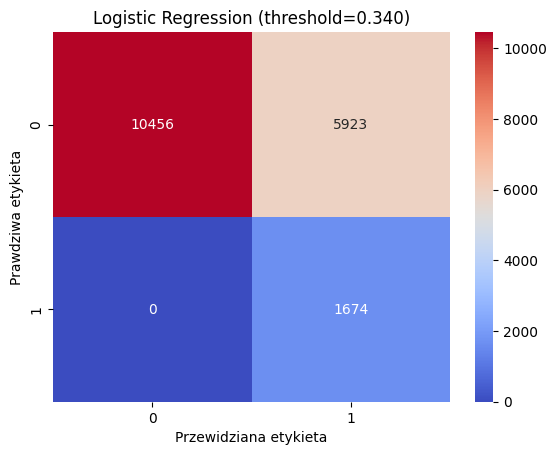


Raport klasyfikacji dla progu strojonego na CV:
              precision    recall  f1-score   support

       False     1.0000    0.6384    0.7793     16379
        True     0.2204    1.0000    0.3611      1674

    accuracy                         0.6719     18053
   macro avg     0.6102    0.8192    0.5702     18053
weighted avg     0.9277    0.6719    0.7405     18053



In [16]:
best = grid.best_estimator_
mask = best.named_steps["select"].get_support()
selected = [n for n, m in zip(feature_names, mask) if m]
print("Wybrane cechy:", selected)

cv_proba = cross_val_predict(
    best,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

thresholds = np.linspace(0.0, 1.0, 201)
cv_costs = []
for thr in thresholds:
    y_cv_pred = (cv_proba >= thr).astype(int)
    cv_costs.append(neo_cost_score(y_train, y_cv_pred))

best_thr = float(thresholds[int(np.argmin(cv_costs))])
print(f"Najlepszy próg (CV): {best_thr:.3f}")
print(f"Minimalny koszt (CV, próg): {min(cv_costs):.0f}")

proba_test = best.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= best_thr).astype(int)


def cost_breakdown(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = neo_cost_score(y_true, y_pred)
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp, "cost": cost}


strategies = {
    "model_threshold_tuned": y_pred,
    "model_threshold_0.5": (proba_test >= 0.5).astype(int),
    "always_hazardous": np.ones_like(y_test, dtype=int),
    "always_non_hazardous": np.zeros_like(y_test, dtype=int),
}

comparison = pd.DataFrame(
    {name: cost_breakdown(y_test, pred) for name, pred in strategies.items()}
).T.sort_values("cost")
print("\nPorównanie strategii (niższy koszt = lepiej):")
print(comparison)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.ylabel("Prawdziwa etykieta")
plt.xlabel("Przewidziana etykieta")
plt.title(f"Logistic Regression (threshold={best_thr:.3f})")
plt.show()

print("\nRaport klasyfikacji dla progu strojonego na CV:")
print(classification_report(y_test, y_pred, digits=4))